In [2]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
os.environ['KERAS_BACKEND'] = 'tensorflow'
from keras.models import Sequential
from keras.layers import Dense, LSTM, Flatten, Conv2D
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, KFold

In [3]:
# Set font type to Arial
plt.rcParams['font.family'] = 'Arial'

In [4]:
lengths = [24,27,36,39]

In [5]:
def process_and_evaluate(file_path, train_size=0.8, n_splits=5):

    import pandas as pd
    import numpy as np
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_squared_error, r2_score
    from sklearn.model_selection import KFold

    # Load the Excel file into a DataFrame
    df = pd.read_excel(file_path)

    # Calculate the log2 averaged enrichment score
    df['log2_averaged_enrichment_score'] = df['averaged_enrichment_score'].apply(lambda x: np.log2(x))

    # Calculate the sizes for train, validation, and test sets
    train_size = int(train_size * len(df))

    # Shuffle and split the data into training, validation, and test sets
    train, test = np.split(df.sample(frac=1), [train_size])

    # One-hot encoding of the amino acid sequences 
    train_x = np.asarray([AA_hotencoding(variant) for variant in train["amino_acid_sequence"]])
    train_y = np.asarray([score for score in train['log2_averaged_enrichment_score']])
    test_x = np.asarray([AA_hotencoding(variant) for variant in test["amino_acid_sequence"]])
    test_y = np.asarray([score for score in test['log2_averaged_enrichment_score']])

    # Perform five-fold cross-validation
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []

    for fold, (train_index, val_index) in enumerate(kf.split(train_x)):
        print(f"Training fold {fold + 1}...")
        
        # Split the data into training and validation sets for the current fold
        x_train_fold, x_val_fold = train_x[train_index], train_x[val_index]
        y_train_fold, y_val_fold = train_y[train_index], train_y[val_index]

        # Reshape the 3D arrays into 2D arrays
        X_train_reshaped = x_train_fold.reshape(x_train_fold.shape[0], -1)
        X_val_reshaped = x_val_fold.reshape(x_val_fold.shape[0], -1)
        
        # Train the model
        model = LinearRegression()
        model.fit(X_train_reshaped, y_train_fold)
        y_pred = model.predict(X_val_reshaped)

        # Calculate pearson correlation coefficient
        corrcoef = np.corrcoef(y_val_fold, y_pred)[0, 1]

        # Append the results to the fold_results list
        fold_results.append(corrcoef)

    return fold_results

In [6]:
def LongShortTermMemoryModel(L1=160, L2=20, length=24):

    """
    
    parent_model builds an LSTM model with paramters that work accross all functional fitness models in the Fit4Function study. 
    L1 and L2 define the sizes of the model two layers. 
    
    """
    length = int(length/3)

    model = Sequential()
    model.add(LSTM(L1, return_sequences=True, input_shape=(length, 20)))
    model.add(LSTM(L2, return_sequences=False))
    model.add(Dense(units=1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

    return model

def Perceptron(L1=160, length=24):

    length = int(length/3)

    model = Sequential()
    model.add(Flatten(input_shape=(length, 20)))
    model.add(Dense(L1))
    model.add(Dense(L1))
    model.add(Dense(units=1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
    return model

def CNN(L1=160, length=24):
    
    length = int(length/3)

    model = Sequential()
    # Add a Conv2D layer with filters that convolve along the height (length) while preserving the width (20)
    model.add(Conv2D(L1, (length, 1), activation='relu', input_shape=(length, 20, 1)))
    # Flatten the output to feed into Dense layers
    model.add(Flatten())
    # Output layer with a single unit for continuous output
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
    return model

In [7]:
def AA_hotencoding(variant):
    
    """
    
    AA_hotencoding takes an amino acid sequence 'variant' of an arbitrary length, 
    and returns a 20xlength one-hot encoding matrix 'onehot_encoded'.   
    
    """
       
    AAs = 'ARNDCQEGHILKMFPSTWYV'
    encoding_length = len(AAs)
    variant_length = len(variant)

    # Define a mapping of chars to integers
    char_to_int = dict((c, i) for i, c in enumerate(AAs))
    int_to_char = dict((i, c) for i, c in enumerate(AAs))

    # Encode input data 
    integer_encoded = [char_to_int[char] for i, char in enumerate(variant) if i <variant_length]
    
    # Start one-hot-encoding
    onehot_encoded = list()
    
    for value in integer_encoded:
        letter = [0 for _ in range(encoding_length)]
        letter[value] = 1
        onehot_encoded.append(letter)
                
    return onehot_encoded

In [8]:
# Starting from read count to perform ablation study

# define numerator and denominator files to calculate enrichment
df_numerator = pd.read_excel("data/Excel/third_round/pre_encapsulation_variant_count.xlsx")
df_denominator = pd.read_excel("data/Excel/third_round/post_encapsulation_variant_count.xlsx")

display(df_numerator.head())

,ID,variant,quality,variant_length,variant_count
0,V350230572L2C003R05800976762/1,CTGCGTGGTGATGTTGGGGGGCCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,7544
1,V350231704L3C001R03000327567/1,AGTAGAGACGCGTAGGGATCCCGTCTCGGGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",31,7541
2,V350230572L1C001R04900519270/1,TTGTCGGATCGTAAGTTTGAACGGCAGGCTAATGTTTTT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,1539
3,V350231704L3C003R01100128026/1,CTGAGTGGGAGGCTGGATATTCTGCCTAAGCTTTTT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,1427
4,V350231704L3C001R02300983205/1,TTGTTTGATCGGCTGGATGTTCTGTCGAGTGGTGCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,1141


In [9]:
# Calculate the sum of all integers in the column "variant_count"
total_variant_count_denominator = df_denominator['variant_count'].sum()
total_variant_count_numerator = df_numerator['variant_count'].sum()

# merging both dataframes
merged_df = pd.merge(df_denominator, df_numerator, on='variant', suffixes=('_denominator', '_numerator'))
display(merged_df.head())

,ID_denominator,variant,quality_denominator,variant_length_denominator,variant_count_denominator,ID_numerator,quality_numerator,variant_length_numerator,variant_count_numerator
0,V350230572L1C003R04900669874/1,CTGCGTGGTGATGTTGGGGGGCCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,58563,V350230572L2C003R05800976762/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,7544
1,V350230572L2C005R01800167223/1,TTGTCGGATCGTAAGTTTGAACGGCAGGCTAATGTTTTT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,17385,V350230572L1C001R04900519270/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,1539
2,V350230572L2C004R03100753574/1,CTGAGTGGGAGGCTGGATATTCTGCCTAAGCTTTTT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,14307,V350231704L3C003R01100128026/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,1427
3,V350230572L1C003R05500568788/1,TTGTTTGATCGGCTGGATGTTCTGTCGAGTGGTGCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,5328,V350231704L3C001R02300983205/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,1141
4,V350230572L1C002R04701161624/1,AGTAGAGACGCGTAGGGATCCCGTCTCGGGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",31,5036,V350231704L3C001R03000327567/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",31,7541


In [10]:
# Introduce read count cutoff which discards ~90% of sequences with stop codons
merged_df = merged_df.loc[merged_df["variant_count_denominator"] >= 32]
merged_df = merged_df.loc[merged_df["variant_count_numerator"] >= 32]
display(merged_df.head())

,ID_denominator,variant,quality_denominator,variant_length_denominator,variant_count_denominator,ID_numerator,quality_numerator,variant_length_numerator,variant_count_numerator
0,V350230572L1C003R04900669874/1,CTGCGTGGTGATGTTGGGGGGCCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,58563,V350230572L2C003R05800976762/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,7544
1,V350230572L2C005R01800167223/1,TTGTCGGATCGTAAGTTTGAACGGCAGGCTAATGTTTTT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,17385,V350230572L1C001R04900519270/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,1539
2,V350230572L2C004R03100753574/1,CTGAGTGGGAGGCTGGATATTCTGCCTAAGCTTTTT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,14307,V350231704L3C003R01100128026/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,1427
3,V350230572L1C003R05500568788/1,TTGTTTGATCGGCTGGATGTTCTGTCGAGTGGTGCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,5328,V350231704L3C001R02300983205/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,1141
4,V350230572L1C002R04701161624/1,AGTAGAGACGCGTAGGGATCCCGTCTCGGGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",31,5036,V350231704L3C001R03000327567/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",31,7541


In [11]:
# Normalize the "variant_count" column
merged_df[f'variant_count_denominator_normalized'] = merged_df[f"variant_count_denominator"] / total_variant_count_denominator
merged_df[f'variant_count_numerator_normalized'] = merged_df[f"variant_count_numerator"] / total_variant_count_numerator

# Create a new column for the division result
merged_df[f'enrichment_score'] = merged_df[f'variant_count_numerator_normalized'] / merged_df[f'variant_count_denominator_normalized']
# log2 transform the enrichment score for each read count divisor
merged_df[f'log2_enrichment_score'] = merged_df[f'enrichment_score'].apply(lambda x: np.log2(x))
display(merged_df.head())

,ID_denominator,variant,quality_denominator,variant_length_denominator,variant_count_denominator,ID_numerator,quality_numerator,variant_length_numerator,variant_count_numerator,variant_count_denominator_normalized,variant_count_numerator_normalized,enrichment_score,log2_enrichment_score
0,V350230572L1C003R04900669874/1,CTGCGTGGTGATGTTGGGGGGCCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,58563,V350230572L2C003R05800976762/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,7544,0.013518,0.001544,0.114206,-3.130292
1,V350230572L2C005R01800167223/1,TTGTCGGATCGTAAGTTTGAACGGCAGGCTAATGTTTTT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,17385,V350230572L1C001R04900519270/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,1539,0.004013,0.000315,0.078483,-3.671482
2,V350230572L2C004R03100753574/1,CTGAGTGGGAGGCTGGATATTCTGCCTAAGCTTTTT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,14307,V350231704L3C003R01100128026/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,1427,0.003303,0.000292,0.088427,-3.499368
3,V350230572L1C003R05500568788/1,TTGTTTGATCGGCTGGATGTTCTGTCGAGTGGTGCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,5328,V350231704L3C001R02300983205/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,1141,0.001230,0.000234,0.189859,-2.397000
4,V350230572L1C002R04701161624/1,AGTAGAGACGCGTAGGGATCCCGTCTCGGGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",31,5036,V350231704L3C001R03000327567/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",31,7541,0.001162,0.001543,1.327557,0.408773


In [ ]:
import pandas as pd
import glob
from Bio.Seq import Seq

# Function to translate DNA sequence to amino acid sequence
def translate_dna_to_protein(dna_seq):
    dna_seq_obj = Seq(dna_seq)
    protein_seq = str(dna_seq_obj.translate())
    return protein_seq

# Translate the 'variant' column and save in a new column 'amino_acid_sequence'
merged_df['amino_acid_sequence'] = merged_df['variant'].apply(translate_dna_to_protein)

/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/Bio/Seq.py:2879: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


In [ ]:
# Get rid of variants with stop codons
merged_df = merged_df[~merged_df.astype(str).apply(lambda row: row.str.contains(r"\*").any(), axis=1)]

'\n# Remove rational designs from the dataset\nrational_motifs = ["YP*L", "PP*Y", "FPIV", "PLPPV", "L**L", "KFERQ", "PSAP", "PTAP"]\n\nimport re\n\n# Function to check if sequence contains any of the motifs\ndef contains_motifs(sequence, motifs):\n    return any(motif for motif in motifs if contains_wildcard_motif(sequence, motif))\n\ndef contains_wildcard_motif(sequence, motif):\n    # Convert the motif to a regex pattern, replacing \'*\' with \'.\'\n    regex_pattern = motif.replace("*", ".")\n    # Search for the pattern in the sequence\n    return re.search(regex_pattern, sequence) is not None\n\nmerged_df = merged_df[~merged_df[\'amino_acid_sequence\'].apply(lambda seq: contains_motifs(seq, rational_motifs))]\ndisplay(merged_df)\n'

In [ ]:
models = {}

for length in lengths:

    subsampled_df = merged_df.loc[merged_df["variant_length_denominator"]==length]

    # GOAL train test split
    # 80% training, 10% validation, 10% test
    train_size = 560
    test_size = 140

    # Split the data into training and test sets
    train, val = np.split(subsampled_df.sample(frac=1), [train_size])

    # GOAL one hot encoding of the amino acid sequences
    train_x = np.asarray([AA_hotencoding(variant) for variant in train["amino_acid_sequence"]])
    train_y = np.asarray([score for score in train[f'log2_enrichment_score']])

    models[f'FNN_{length}'] = [Perceptron, length, train_x, train_y]
    models[f'LSTM_{length}'] = [LongShortTermMemoryModel, length, train_x, train_y]
    models[f'CNN_{length}'] = [CNN, length, train_x, train_y]

,ID_denominator,variant,quality_denominator,variant_length_denominator,variant_count_denominator,ID_numerator,quality_numerator,variant_length_numerator,variant_count_numerator,variant_count_denominator_normalized,variant_count_numerator_normalized,enrichment_score,log2_enrichment_score,amino_acid_sequence
0,V350230572L1C003R04900669874/1,CTGCGTGGTGATGTTGGGGGGCCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,58563,V350230572L2C003R05800976762/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,7544,0.013518,0.001544,0.114206,-3.130292,LRGDVGGP
5,V350230572L1C004R05700108921/1,AGGCGGGCGGATACTTGTAGTGCG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,4796,V350230572L1C001R04800561978/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,696,0.001107,0.000142,0.128659,-2.958377,RRADTCSA
6,V350230572L2C003R03701213307/1,CATAAGGAGCATTGTGCTACGAGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,4449,V350231704L3C003R02301264686/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,543,0.001027,0.000111,0.108205,-3.208161,HKEHCATS
8,V350230572L1C002R07100567629/1,ACTGCGCCTGGGGTTCATTGTGGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,3297,V350230572L1C001R04201058623/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,733,0.000761,0.000150,0.197104,-2.342973,TAPGVHCG
10,V350230572L2C004R02300026454/1,AGGTGTGTTGATCAGAAGGTTTCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,3172,V350231704L3C002R00501383900/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,389,0.000732,0.000080,0.108724,-3.201255,RCVDQKVS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20024,V350230572L1C002R06200262886/1,AGGTTTCCCACCGCCCCGCTTGCG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,32,V350231704L3C001R03601019270/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,33,0.000007,0.000007,0.914269,-0.129310,RFPTAPLA
20025,V350230572L2C005R01700967496/1,TCTAAGCACCACATTTACAATAGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,32,V350230572L2C002R00900670455/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,35,0.000007,0.000007,0.969679,-0.044421,SKHHIYNS
20030,V350230572L1C002R01900139577/1,TATACGCCCACCGCCCCGAGTCGG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,32,V350231704L3C003R02500604056/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,40,0.000007,0.000008,1.108204,0.148224,YTPTAPSR
20039,V350230572L2C003R05500966198/1,AAGCTGCACCACGTTTACCCGAGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,32,V350231704L3C003R05500705740/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,47,0.000007,0.000010,1.302140,0.380885,KLHHVYPS


/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


,ID_denominator,variant,quality_denominator,variant_length_denominator,variant_count_denominator,ID_numerator,quality_numerator,variant_length_numerator,variant_count_numerator,variant_count_denominator_normalized,variant_count_numerator_normalized,enrichment_score,log2_enrichment_score,amino_acid_sequence
48,V350230572L2C004R00500404762/1,CGTTCTCCGCTCCCTCCTGTGTGTGGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,1081,V350231704L3C003R00401125442/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,263,0.000250,0.000054,0.215695,-2.212936,RSPLPPVCG
60,V350230572L2C003R04800821581/1,CGGACGCCGCTCCCTCCTGTGTGTAGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,898,V350231704L3C002R05000544694/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,92,0.000207,0.000019,0.090828,-3.460714,RTPLPPVCS
64,V350230572L2C003R06300525560/1,AGGTCTCCGCTCCCTCCTGTGTGTGCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,880,V350230572L2C003R05600513941/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,206,0.000203,0.000042,0.207536,-2.268563,RSPLPPVCA
72,V350230572L1C002R02400871220/1,AAGTGTCCGCTCCCTCCTGTGATTAGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,839,V350231704L3C003R05900714656/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,166,0.000194,0.000034,0.175411,-2.511192,KCPLPPVIS
77,V350230572L1C002R02000210992/1,AGGAGTCCGCTCCCTCCTGTGTGTTCG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,798,V350230572L2C002R05100904403/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,164,0.000184,0.000034,0.182201,-2.456397,RSPLPPVCS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20029,V350230572L2C003R01601029051/1,GGGAGTCCGCTCCCTCCTGTGGATCGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,32,V350231704L3C002R00800702999/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,33,0.000007,0.000007,0.914269,-0.129310,GSPLPPVDR
20033,V350230572L1C002R00501225349/1,TTTTCTAAGTTTGAACGGCAGTTTTTT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,32,V350231704L3C001R00100071833/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,39,0.000007,0.000008,1.080499,0.111698,FSKFERQFF
20037,V350230572L2C001R05901381133/1,GTTCTGCCGCTCCCTCCTGTGTATAGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,32,V350230572L1C003R05900773682/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,68,0.000007,0.000014,1.883947,0.913759,VLPLPPVYS
20038,V350230572L1C004R04700737196/1,CATAAGCCGCTCCCTCCTGTGAATGTG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,32,V350230572L1C002R03400987854/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,37,0.000007,0.000008,1.025089,0.035749,HKPLPPVNV


/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


,ID_denominator,variant,quality_denominator,variant_length_denominator,variant_count_denominator,ID_numerator,quality_numerator,variant_length_numerator,variant_count_numerator,variant_count_denominator_normalized,variant_count_numerator_normalized,enrichment_score,log2_enrichment_score,amino_acid_sequence
2,V350230572L2C004R03100753574/1,CTGAGTGGGAGGCTGGATATTCTGCCTAAGCTTTTT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,14307,V350231704L3C003R01100128026/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,1427,0.003303,0.000292,0.088427,-3.499368,LSGRLDILPKLF
3,V350230572L1C003R05500568788/1,TTGTTTGATCGGCTGGATGTTCTGTCGAGTGGTGCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,5328,V350231704L3C001R02300983205/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,1141,0.001230,0.000234,0.189859,-2.397000,LFDRLDVLSSGA
9,V350230572L1C004R07000498585/1,TTTCTTAGTGCGCCCACCGCCCCGAATGTGAAGCAG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,3191,V350231704L3C002R01800517356/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,813,0.000737,0.000166,0.225878,-2.146386,FLSAPTAPNVKQ
11,V350230572L2C002R05600399031/1,GTTTGTAGGGTGGGTAATGCTGATGAGAGGGCGAGG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,3100,V350230572L2C003R07200700472/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,474,0.000716,0.000097,0.135558,-2.883014,VCRVGNADERAR
15,V350230572L1C001R04901109286/1,AGGTTGTCGCCTCACCACAAGTACGGGTCTGATATT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,2481,V350230572L1C003R02601156108/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,117,0.000573,0.000024,0.041809,-4.580046,RLSPHHKYGSDI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19892,V350230572L1C004R05700306713/1,GAGTTGGAGGTGTTCCACATCGTGATTATTGTGTTG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,32,V350231704L3C003R02200740863/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,35,0.000007,0.000007,0.969679,-0.044421,ELEVFHIVIIVL
19918,V350230572L1C004R05800995069/1,TTTGGTTATTTTCTGTTTATTCTGTTTTGTGTTAAT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,32,V350230572L1C003R04000831654/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,129,0.000007,0.000026,3.573959,1.837523,FGYFLFILFCVN
19962,V350230572L1C001R03400223268/1,CGGGTTGTTAGGCCCTCCGCCCCGAGTATTTATGGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,32,V350231704L3C003R00601354094/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,37,0.000007,0.000008,1.025089,0.035749,RVVRPSAPSIYG
19984,V350230572L1C004R06500010073/1,TATACTAATACTTTGCCTTTGCATAGTTGGTGTATT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,32,V350231704L3C003R06700886235/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,42,0.000007,0.000009,1.163614,0.218613,YTNTLPLHSWCI


/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


,ID_denominator,variant,quality_denominator,variant_length_denominator,variant_count_denominator,ID_numerator,quality_numerator,variant_length_numerator,variant_count_numerator,variant_count_denominator_normalized,variant_count_numerator_normalized,enrichment_score,log2_enrichment_score,amino_acid_sequence
1,V350230572L2C005R01800167223/1,TTGTCGGATCGTAAGTTTGAACGGCAGGCTAATGTTTTT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,17385,V350230572L1C001R04900519270/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,1539,0.004013,0.000315,0.078483,-3.671482,LSDRKFERQANVF
44,V350230572L1C004R05200919834/1,ATTCTTACGCCTAAGTTTGAACGGCAGAGTAATTGTGAT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,1237,V350230572L1C003R00700640860/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,590,0.000286,0.000121,0.422856,-1.241763,ILTPKFERQSNCD
85,V350230572L1C002R01700504960/1,GGGCAGAATGCTAAGTTTGAACGGCAGTGTGATCATGCG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,761,V350230572L1C002R05601215390/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,189,0.000176,0.000039,0.220185,-2.183214,GQNAKFERQCDHA
100,V350230572L1C003R01601371590/1,GGGGAGTGTGTGAAGTTTGAACGGCAGACTAAGTTGGGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,695,V350231704L3C003R00600111235/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,277,0.000160,0.000057,0.353350,-1.500831,GECVKFERQTKLG
114,V350230572L2C005R00700598868/1,ATTTCGTGTGCTAAGTTTGAACGGCAGGATAGGGATTCG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,639,V350231704L3C003R02000194187/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,200,0.000148,0.000041,0.277485,-1.849520,ISCAKFERQDRDS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19727,V350230572L1C001R04400876074/1,GTTACTCTTGATAAGTTTGAACGGCAGCCTTATATTTTG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,32,V350230572L1C003R06500773475/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,49,0.000007,0.000010,1.357550,0.441006,VTLDKFERQPYIL
19754,V350230572L2C005R01000535619/1,TTTACTGGTGCTAAGTTTGAACGGCAGGGGATTCTTGAG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,32,V350230572L2C001R00100725408/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,42,0.000007,0.000009,1.163614,0.218613,FTGAKFERQGILE
19866,V350230572L2C004R00800965082/1,TTGTTTTTTAATAAGTTTGAACGGCAGGGTTATGATACT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,32,V350231704L3C002R05201236145/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,32,0.000007,0.000007,0.886563,-0.173704,LFFNKFERQGYDT
19920,V350230572L1C003R02601149858/1,GGGAGTCGGTGTAAGTTTGAACGGCAGGAGGGTTGTCCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,32,V350230572L1C001R04000475087/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,41,0.000007,0.000008,1.135909,0.183848,GSRCKFERQEGCP


/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [15]:
pearson_results = {model_name: [] for model_name in models.keys()}

In [18]:
# Define the number of folds
kf = KFold(n_splits=10, shuffle=True, random_state=60)

for model_name, model_params in models.items():
    model_func = model_params[0]
    length = model_params[1]
    train_x = model_params[2]
    train_y = model_params[3]

    fold = 1
    fold_results = []

    for train_index, val_index in kf.split(train_x):
        
        print(f"Training fold {fold} for {model_name}...")
        
        # Split the data into training and validation sets
        X_train, X_val = train_x[train_index], train_x[val_index]
        y_train, y_val = train_y[train_index], train_y[val_index]
        
        # Create the model
        model = model_func(length=length)
        
        # Train the model
        model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=50,
            batch_size=500,
            verbose=0
        )
        
        # Evaluate the model on the validation set
        val_loss, val_mae = model.evaluate(X_val, y_val, verbose=0)

        # Store the results for the current model
        y_pred = model.predict(X_val)
        y_pred = np.reshape(y_pred, (1,y_pred.shape[0]))[0]
        pearson_corr = np.corrcoef(y_val, y_pred)[0, 1]
        pearson_results[model_name].append(pearson_corr)
        print(f"Pearson for {model_name} {fold}: {pearson_results[model_name]}")
        
        fold += 1

/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training fold 1 for FNN_24...


W0000 00:00:1786196499.402764  592847 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Pearson for FNN_24 1: [0.5460042108055702]
Training fold 2 for FNN_24...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Pearson for FNN_24 2: [0.5460042108055702, 0.6553650147268326]
Training fold 3 for FNN_24...
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x710de6436840> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.

/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
Pearson for LSTM_24 1: [0.5140350771687154]
Training fold 2 for LSTM_24...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
Pearson for LSTM_24 2: [0.5140350771687154, 0.6613302990259715]
Training fold 3 for LSTM_24...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
Pearson for LSTM_24 3: [0.5140350771687154, 0.6613302990259715, 0.6244176623421656]
Training fold 4 for LSTM_24...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
Pearson for LSTM_24 4: [0.5140350771687154, 0.6613302990259715, 0.6244176623421656, 0.5915664812039425]
Training fold 5 for LSTM_24...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
Pearson for LSTM_24 5: [0.5140350771687154, 0.6613302990259715, 0.6244176623421656, 0.5915664812039425, 0.420851075952659]
Training fold 6 for LSTM_24...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
Pearson for LSTM_24 6: [0.5140350771687154, 0.6613302990259715, 0.6244176623421656, 0.5915664812039425, 0.420851075952659, 0.5499289520447611]
Training fold 7 for LSTM_24...
2/2 ━━━━━━━━━━━━━━

/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Pearson for CNN_24 1: [0.5276362509820353]
Training fold 2 for CNN_24...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Pearson for CNN_24 2: [0.5276362509820353, 0.609383558443014]
Training fold 3 for CNN_24...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Pearson for CNN_24 3: [0.5276362509820353, 0.609383558443014, 0.6186313466860558]
Training fold 4 for CNN_24...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Pearson for CNN_24 4: [0.5276362509820353, 0.609383558443014, 0.6186313466860558, 0.644233585801735]
Training fold 5 for CNN_24...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Pearson for CNN_24 5: [0.5276362509820353, 0.609383558443014, 0.6186313466860558, 0.644233585801735, 0.4822097675923839]
Training fold 6 for CNN_24...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Pearson for CNN_24 6: [0.5276362509820353, 0.609383558443014, 0.6186313466860558, 0.644233585801735, 0.4822097675923839, 0.5617419596857307]
Training fold 7 for CNN_24...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Pear

In [ ]:
# Define the number of folds
kf = KFold(n_splits=10, shuffle=True, random_state=55)
for length in lengths:

    subsampled_df = merged_df.loc[merged_df["variant_length_denominator"]==length]

    # GOAL one hot encoding of the amino acid sequences
    train_x = np.asarray([AA_hotencoding(variant) for variant in subsampled_df["amino_acid_sequence"]])
    train_y = np.asarray([score for score in subsampled_df[f'log2_enrichment_score']])
    fold_results = []
    fold = 1

    for train_index, val_index in kf.split(train_x):
        print(f"Training fold {fold}...")
        
        # Split the data into training and validation sets
        X_train, X_val = train_x[train_index], train_x[val_index]
        y_train, y_val = train_y[train_index], train_y[val_index]

        # Reshape the 3D arrays into 2D arrays
        X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
        X_val_reshaped = X_val.reshape(X_val.shape[0], -1)
        
        # Train the model
        model = LinearRegression()
        model.fit(X_train_reshaped, y_train)
        y_pred = model.predict(X_val_reshaped)

        # Calculate pearson correlation coefficient
        corrcoef = np.corrcoef(y_val, y_pred)[0, 1]
        # Append the results to the fold_results list
        fold_results.append(corrcoef)
        print(f"Pearson for LR_{length} {fold}: {corrcoef}")
        fold += 1

    pearson_results[f'LR_{length}'] = fold_results    

,ID_denominator,variant,quality_denominator,variant_length_denominator,variant_count_denominator,ID_numerator,quality_numerator,variant_length_numerator,variant_count_numerator,variant_count_denominator_normalized,variant_count_numerator_normalized,enrichment_score,log2_enrichment_score,amino_acid_sequence
0,V350230572L1C003R04900669874/1,CTGCGTGGTGATGTTGGGGGGCCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,58563,V350230572L2C003R05800976762/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,7544,0.013518,0.001544,0.114206,-3.130292,LRGDVGGP
5,V350230572L1C004R05700108921/1,AGGCGGGCGGATACTTGTAGTGCG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,4796,V350230572L1C001R04800561978/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,696,0.001107,0.000142,0.128659,-2.958377,RRADTCSA
6,V350230572L2C003R03701213307/1,CATAAGGAGCATTGTGCTACGAGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,4449,V350231704L3C003R02301264686/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,543,0.001027,0.000111,0.108205,-3.208161,HKEHCATS
8,V350230572L1C002R07100567629/1,ACTGCGCCTGGGGTTCATTGTGGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,3297,V350230572L1C001R04201058623/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,733,0.000761,0.000150,0.197104,-2.342973,TAPGVHCG
10,V350230572L2C004R02300026454/1,AGGTGTGTTGATCAGAAGGTTTCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,3172,V350231704L3C002R00501383900/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,389,0.000732,0.000080,0.108724,-3.201255,RCVDQKVS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20024,V350230572L1C002R06200262886/1,AGGTTTCCCACCGCCCCGCTTGCG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,32,V350231704L3C001R03601019270/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,33,0.000007,0.000007,0.914269,-0.129310,RFPTAPLA
20025,V350230572L2C005R01700967496/1,TCTAAGCACCACATTTACAATAGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,32,V350230572L2C002R00900670455/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,35,0.000007,0.000007,0.969679,-0.044421,SKHHIYNS
20030,V350230572L1C002R01900139577/1,TATACGCCCACCGCCCCGAGTCGG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,32,V350231704L3C003R02500604056/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,40,0.000007,0.000008,1.108204,0.148224,YTPTAPSR
20039,V350230572L2C003R05500966198/1,AAGCTGCACCACGTTTACCCGAGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,32,V350231704L3C003R05500705740/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,47,0.000007,0.000010,1.302140,0.380885,KLHHVYPS


Training fold 1...
Pearson for LR_24 1: 0.710745282850109
Training fold 2...
Pearson for LR_24 2: 0.7491510890651645
Training fold 3...
Pearson for LR_24 3: 0.6989986230907105
Training fold 4...
Pearson for LR_24 4: 0.6999034483796295
Training fold 5...
Pearson for LR_24 5: 0.7216045965381455
Training fold 6...
Pearson for LR_24 6: 0.7014524731167223
Training fold 7...
Pearson for LR_24 7: 0.6968063682005141
Training fold 8...
Pearson for LR_24 8: 0.6883707611476644
Training fold 9...
Pearson for LR_24 9: 0.7167906350676816
Training fold 10...
Pearson for LR_24 10: 0.680035825216506


,ID_denominator,variant,quality_denominator,variant_length_denominator,variant_count_denominator,ID_numerator,quality_numerator,variant_length_numerator,variant_count_numerator,variant_count_denominator_normalized,variant_count_numerator_normalized,enrichment_score,log2_enrichment_score,amino_acid_sequence
48,V350230572L2C004R00500404762/1,CGTTCTCCGCTCCCTCCTGTGTGTGGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,1081,V350231704L3C003R00401125442/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,263,0.000250,0.000054,0.215695,-2.212936,RSPLPPVCG
60,V350230572L2C003R04800821581/1,CGGACGCCGCTCCCTCCTGTGTGTAGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,898,V350231704L3C002R05000544694/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,92,0.000207,0.000019,0.090828,-3.460714,RTPLPPVCS
64,V350230572L2C003R06300525560/1,AGGTCTCCGCTCCCTCCTGTGTGTGCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,880,V350230572L2C003R05600513941/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,206,0.000203,0.000042,0.207536,-2.268563,RSPLPPVCA
72,V350230572L1C002R02400871220/1,AAGTGTCCGCTCCCTCCTGTGATTAGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,839,V350231704L3C003R05900714656/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,166,0.000194,0.000034,0.175411,-2.511192,KCPLPPVIS
77,V350230572L1C002R02000210992/1,AGGAGTCCGCTCCCTCCTGTGTGTTCG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,798,V350230572L2C002R05100904403/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,164,0.000184,0.000034,0.182201,-2.456397,RSPLPPVCS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20029,V350230572L2C003R01601029051/1,GGGAGTCCGCTCCCTCCTGTGGATCGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,32,V350231704L3C002R00800702999/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,33,0.000007,0.000007,0.914269,-0.129310,GSPLPPVDR
20033,V350230572L1C002R00501225349/1,TTTTCTAAGTTTGAACGGCAGTTTTTT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,32,V350231704L3C001R00100071833/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,39,0.000007,0.000008,1.080499,0.111698,FSKFERQFF
20037,V350230572L2C001R05901381133/1,GTTCTGCCGCTCCCTCCTGTGTATAGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,32,V350230572L1C003R05900773682/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,68,0.000007,0.000014,1.883947,0.913759,VLPLPPVYS
20038,V350230572L1C004R04700737196/1,CATAAGCCGCTCCCTCCTGTGAATGTG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,32,V350230572L1C002R03400987854/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",27,37,0.000007,0.000008,1.025089,0.035749,HKPLPPVNV


Training fold 1...
Pearson for LR_27 1: 0.6258227998488404
Training fold 2...
Pearson for LR_27 2: 0.003676377001436534
Training fold 3...
Pearson for LR_27 3: 0.05533536460347772
Training fold 4...
Pearson for LR_27 4: 0.06322023873288697
Training fold 5...
Pearson for LR_27 5: -0.007626535739314155
Training fold 6...
Pearson for LR_27 6: 0.5362753946525656
Training fold 7...
Pearson for LR_27 7: -0.08466290532914036
Training fold 8...
Pearson for LR_27 8: -0.1359341970280531
Training fold 9...
Pearson for LR_27 9: 0.05972440066587099
Training fold 10...
Pearson for LR_27 10: 0.5836521150012096


,ID_denominator,variant,quality_denominator,variant_length_denominator,variant_count_denominator,ID_numerator,quality_numerator,variant_length_numerator,variant_count_numerator,variant_count_denominator_normalized,variant_count_numerator_normalized,enrichment_score,log2_enrichment_score,amino_acid_sequence
2,V350230572L2C004R03100753574/1,CTGAGTGGGAGGCTGGATATTCTGCCTAAGCTTTTT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,14307,V350231704L3C003R01100128026/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,1427,0.003303,0.000292,0.088427,-3.499368,LSGRLDILPKLF
3,V350230572L1C003R05500568788/1,TTGTTTGATCGGCTGGATGTTCTGTCGAGTGGTGCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,5328,V350231704L3C001R02300983205/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,1141,0.001230,0.000234,0.189859,-2.397000,LFDRLDVLSSGA
9,V350230572L1C004R07000498585/1,TTTCTTAGTGCGCCCACCGCCCCGAATGTGAAGCAG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,3191,V350231704L3C002R01800517356/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,813,0.000737,0.000166,0.225878,-2.146386,FLSAPTAPNVKQ
11,V350230572L2C002R05600399031/1,GTTTGTAGGGTGGGTAATGCTGATGAGAGGGCGAGG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,3100,V350230572L2C003R07200700472/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,474,0.000716,0.000097,0.135558,-2.883014,VCRVGNADERAR
15,V350230572L1C001R04901109286/1,AGGTTGTCGCCTCACCACAAGTACGGGTCTGATATT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,2481,V350230572L1C003R02601156108/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,117,0.000573,0.000024,0.041809,-4.580046,RLSPHHKYGSDI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19892,V350230572L1C004R05700306713/1,GAGTTGGAGGTGTTCCACATCGTGATTATTGTGTTG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,32,V350231704L3C003R02200740863/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,35,0.000007,0.000007,0.969679,-0.044421,ELEVFHIVIIVL
19918,V350230572L1C004R05800995069/1,TTTGGTTATTTTCTGTTTATTCTGTTTTGTGTTAAT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,32,V350230572L1C003R04000831654/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,129,0.000007,0.000026,3.573959,1.837523,FGYFLFILFCVN
19962,V350230572L1C001R03400223268/1,CGGGTTGTTAGGCCCTCCGCCCCGAGTATTTATGGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,32,V350231704L3C003R00601354094/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,37,0.000007,0.000008,1.025089,0.035749,RVVRPSAPSIYG
19984,V350230572L1C004R06500010073/1,TATACTAATACTTTGCCTTTGCATAGTTGGTGTATT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,32,V350231704L3C003R06700886235/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,42,0.000007,0.000009,1.163614,0.218613,YTNTLPLHSWCI


Training fold 1...
Pearson for LR_36 1: 0.5249966991362884
Training fold 2...
Pearson for LR_36 2: 0.5470396235594466
Training fold 3...
Pearson for LR_36 3: 0.4862340264372837
Training fold 4...
Pearson for LR_36 4: 0.5277201178796916
Training fold 5...
Pearson for LR_36 5: 0.46610358165010146
Training fold 6...
Pearson for LR_36 6: 0.6026952437139326
Training fold 7...
Pearson for LR_36 7: 0.4702425691830392
Training fold 8...
Pearson for LR_36 8: 0.4925955561391506
Training fold 9...
Pearson for LR_36 9: 0.5781321425516546
Training fold 10...
Pearson for LR_36 10: 0.6024981716309513


,ID_denominator,variant,quality_denominator,variant_length_denominator,variant_count_denominator,ID_numerator,quality_numerator,variant_length_numerator,variant_count_numerator,variant_count_denominator_normalized,variant_count_numerator_normalized,enrichment_score,log2_enrichment_score,amino_acid_sequence
1,V350230572L2C005R01800167223/1,TTGTCGGATCGTAAGTTTGAACGGCAGGCTAATGTTTTT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,17385,V350230572L1C001R04900519270/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,1539,0.004013,0.000315,0.078483,-3.671482,LSDRKFERQANVF
44,V350230572L1C004R05200919834/1,ATTCTTACGCCTAAGTTTGAACGGCAGAGTAATTGTGAT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,1237,V350230572L1C003R00700640860/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,590,0.000286,0.000121,0.422856,-1.241763,ILTPKFERQSNCD
85,V350230572L1C002R01700504960/1,GGGCAGAATGCTAAGTTTGAACGGCAGTGTGATCATGCG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,761,V350230572L1C002R05601215390/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,189,0.000176,0.000039,0.220185,-2.183214,GQNAKFERQCDHA
100,V350230572L1C003R01601371590/1,GGGGAGTGTGTGAAGTTTGAACGGCAGACTAAGTTGGGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,695,V350231704L3C003R00600111235/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,277,0.000160,0.000057,0.353350,-1.500831,GECVKFERQTKLG
114,V350230572L2C005R00700598868/1,ATTTCGTGTGCTAAGTTTGAACGGCAGGATAGGGATTCG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,639,V350231704L3C003R02000194187/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,200,0.000148,0.000041,0.277485,-1.849520,ISCAKFERQDRDS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19727,V350230572L1C001R04400876074/1,GTTACTCTTGATAAGTTTGAACGGCAGCCTTATATTTTG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,32,V350230572L1C003R06500773475/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,49,0.000007,0.000010,1.357550,0.441006,VTLDKFERQPYIL
19754,V350230572L2C005R01000535619/1,TTTACTGGTGCTAAGTTTGAACGGCAGGGGATTCTTGAG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,32,V350230572L2C001R00100725408/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,42,0.000007,0.000009,1.163614,0.218613,FTGAKFERQGILE
19866,V350230572L2C004R00800965082/1,TTGTTTTTTAATAAGTTTGAACGGCAGGGTTATGATACT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,32,V350231704L3C002R05201236145/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,32,0.000007,0.000007,0.886563,-0.173704,LFFNKFERQGYDT
19920,V350230572L1C003R02601149858/1,GGGAGTCGGTGTAAGTTTGAACGGCAGGAGGGTTGTCCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,32,V350230572L1C001R04000475087/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,41,0.000007,0.000008,1.135909,0.183848,GSRCKFERQEGCP


Training fold 1...
Pearson for LR_39 1: 0.45066203084067213
Training fold 2...
Pearson for LR_39 2: 0.2644407570992419
Training fold 3...
Pearson for LR_39 3: 0.23488252541096538
Training fold 4...
Pearson for LR_39 4: 0.4102108675796668
Training fold 5...
Pearson for LR_39 5: 0.11003651397959667
Training fold 6...
Pearson for LR_39 6: 0.3799952480844555
Training fold 7...
Pearson for LR_39 7: 0.3776319203434754
Training fold 8...
Pearson for LR_39 8: 0.12018177438103723
Training fold 9...
Pearson for LR_39 9: 0.11989415865971564
Training fold 10...
Pearson for LR_39 10: -0.022887125258555036


In [21]:
# Set font properties
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 24

In [ ]:
from statistics import mean

averages = {
    key: mean(values)
    for key, values in pearson_results.items()
}

errors = {
    key: np.std(values)
    for key, values in pearson_results.items()
}
print(errors)
print(averages)

from collections import defaultdict

model_results = defaultdict(list)

model_errors = defaultdict(list)

for key, avg in averages.items():
    model, threshold = key.split("_")
    model_results[model].append((int(threshold), avg))

for key, error in errors.items():
    model, threshold = key.split("_")
    model_errors[model].append((int(threshold), error))

print(model_results)
print(model_errors)

final = {}
final_errors = {}

for model, values in model_results.items():
    values.sort(key=lambda x: x[0])        # sort by threshold
    final[model] = [avg for _, avg in values]

for model, values in model_errors.items():
    values.sort(key=lambda x: x[0])        # sort by threshold
    final_errors[model] = [error for _, error in values]


final_lists = {k: [v for v in vals] for k, vals in final.items()}
final_error_lists = {k: [v for v in vals] for k, vals in final_errors.items()}

{'FNN_24': 0.08385886343788569, 'LSTM_24': 0.08114021961556143, 'CNN_24': 0.04791988787465563, 'FNN_27': 0.1267439656683156, 'LSTM_27': 0.08473403637065346, 'CNN_27': 0.13223386474451979, 'FNN_36': 0.12412511693361908, 'LSTM_36': 0.12230722064236589, 'CNN_36': 0.10408834440113196, 'FNN_39': 0.10704805200729765, 'LSTM_39': 0.10362505585764592, 'CNN_39': 0.08838053902703466, 'LR_24': 0.0184913620081931, 'LR_27': 0.27702245413951526, 'LR_36': 0.049138394638547106, 'LR_39': 0.15069638853681946}
{'FNN_24': 0.5737241821024638, 'LSTM_24': 0.5931081305804174, 'CNN_24': 0.5614996789056967, 'FNN_27': 0.37883572551995537, 'LSTM_27': 0.39610364599490777, 'CNN_27': 0.4657527343447634, 'FNN_36': 0.38701982681502667, 'LSTM_36': 0.5683759680621797, 'CNN_36': 0.5554442987831664, 'FNN_39': 0.31118092363273664, 'LSTM_39': 0.37922562448899133, 'CNN_39': 0.37227265506566376, 'LR_24': 0.7063859102672847, 'LR_27': 0.169948305240978, 'LR_36': 0.529825773188154, 'LR_39': 0.24450486711202718}
defaultdict(<class

,FNN,LSTM,CNN,LR
0,0.573724,0.593108,0.561500,0.706386
1,0.378836,0.396104,0.465753,0.169948
2,0.387020,0.568376,0.555444,0.529826
3,0.311181,0.379226,0.372273,0.244505


,FNN,LSTM,CNN,LR
0,0.083859,0.081140,0.047920,0.018491
1,0.126744,0.084734,0.132234,0.277022
2,0.124125,0.122307,0.104088,0.049138
3,0.107048,0.103625,0.088381,0.150696


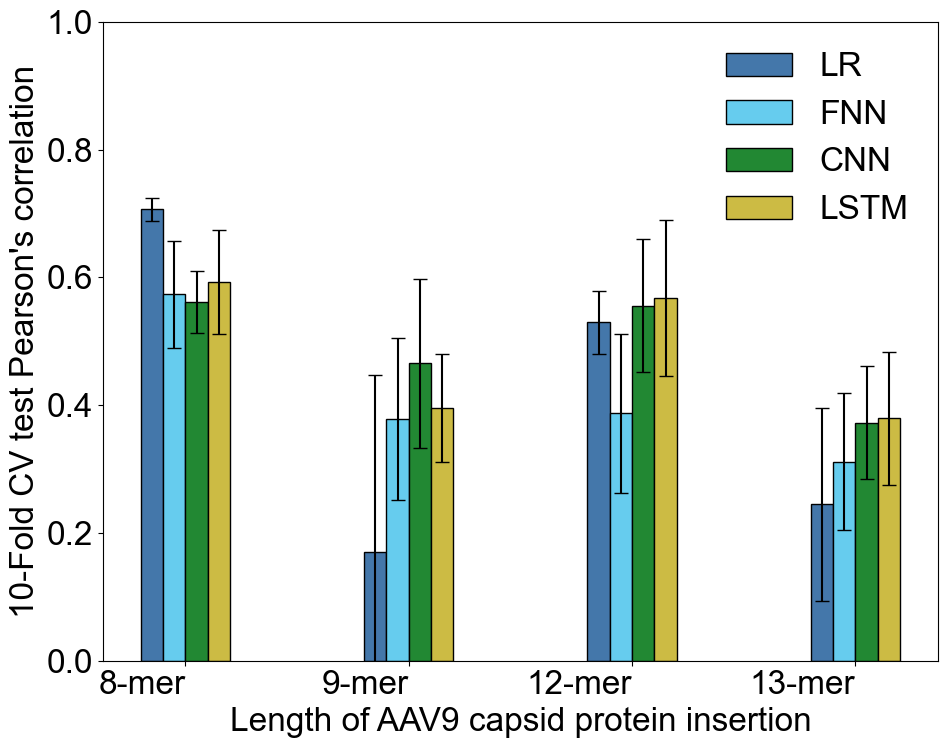

In [ ]:
# --- Bar plot: average Pearson r per model for insert lengths 24 and 36 ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paul Tol's Notes color scheme
colors = ['#4477AA','#66CCEE','#228833','#CCBB44','#EE6677','#AA3377','#BBBBBB']

bar_df = pd.DataFrame(final_lists)

# Error values (e.g., std or standard error)
error_df = pd.DataFrame(final_errors)

target_lengths = lengths

# plotting

fig, ax = plt.subplots(figsize=(10,8))

x = np.arange(len(bar_df))
for i, model in enumerate(["LR", "FNN", "CNN", "LSTM"]):
    ax.bar(x + i*0.1, bar_df[(model)].values, width=0.1, label=f'{model}', color=colors[i], edgecolor='black', yerr=error_df[(model)].values, capsize=5)

ax.set_xticks(x + 0.1*(len(target_lengths)-1)/2)
ax.set_xticklabels(["8-mer", "9-mer", "12-mer", "13-mer"], ha='right')
ax.set_ylabel("10-Fold CV test Pearson's correlation")
ax.set_xlabel("Length of AAV9 capsid protein insertion")
ax.set_ylim(0,1)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('plots/figure_4b.png')
plt.show()
